generating data for 0.25 seconds, dt=2.5e-05


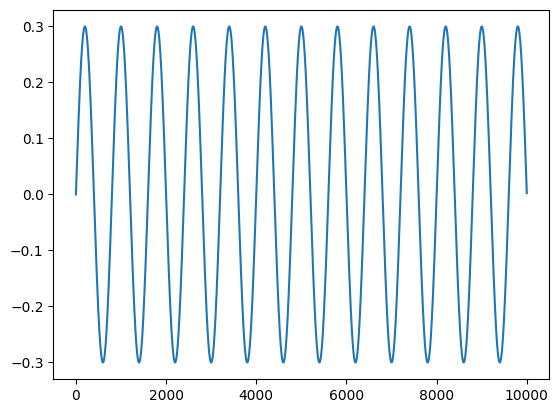

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt



### SYSTEM PARAMETERS ###

k = (2*np.pi*100)**2
m = 1
zeta, f_n = 0.015, 100.0      # 100 Hz
wn = 2 * np.pi * f_n
c = 2 * zeta * m * wn


### CHANGEABLE VARIABLES ###
dt = 0.000025
N = 10000
time = dt*N
t = np.arange(N) * dt
forcetext = 'sin(2pi500t)'
u =  0.3*np.sin(2*np.pi*50*t)

def generate(dt, N, u):
    x = np.zeros(N)
    v = np.zeros(N)
    t = np.arange(N) * dt

    for i in range(1, N):
        acc = -(c/m)*v[i-1] - (k/m)*x[i-1] + (1/m)*u[i-1]
        v[i] = v[i-1] + dt * acc
        x[i] = x[i-1] + dt * v[i]

    return [t,u, x, v]


print(f'generating data for {time} seconds, dt={dt}')

data = generate(dt,N,u)


[t,u,x,v] = data
plt.plot(u)
plt.show()




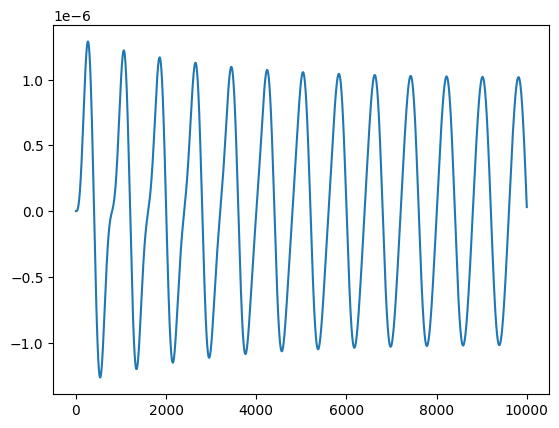

In [2]:
plt.plot(x)

In [ ]:
filename = f'N={N}-dt={dt}-force={forcetext}.txt'

tstr = '\t'.join(str(x) for lst in data for x in lst)

with open(filename, "w") as f:
  f.write(tstr)


# [t,u,x,v] = data
